# GWRATES complete example

This notebook is created by [Phurailatpam Hemantakumar](https://hemantaph.com).

[![Documentation](https://img.shields.io/badge/ler-documentation-blue)](https://ler.hemantaph.com) 

GWRATES is a comprehensive framework for simulating gravitational wave (GW) events and calculating their detection rates. This notebook provides a complete example of CBC event simulation and rate calculation.

## Table of Contents

1. [Part 1: Basic GW Event Simulation and Rate Calculation (BBH Example)](#part-1-basic-gw-event-simulation-and-rate-calculation-bbh-example)
   - [1.1 Initialize GWRATES](#11-initialize-gwrates)
   - [1.2 Simulate GW Population](#12-simulate-gw-population)
   - [1.3 Calculate Detection Rates](#13-calculate-detection-rates)
   - [1.4 Inspect Generated Parameters](#14-inspect-generated-parameters)
   - [1.5 Access Saved Data Files](#15-access-saved-data-files)
   - [1.6 Load and Examine Saved Parameters](#16-load-and-examine-saved-parameters)
   - [1.7 Examine Available Prior Functions](#17-examine-available-prior-functions)
   - [1.8 Visualize Parameter Distributions](#18-visualize-parameter-distributions)

2. [Part 2: Custom Functions and Parameters](#part-2-custom-functions-and-parameters)
   - [2.1 Define Custom Source Frame Masses](#21-define-custom-source-frame-masses)
   - [2.2 Define Event Type with Non-Spinning Configuration](#22-define-event-type-with-non-spinning-configuration)
   - [2.3 Define Custom Merger Rate Density](#23-define-custom-merger-rate-density)
   - [2.4 Define Custom Detection Criteria](#24-define-custom-detection-criteria)
   - [2.5 Initialize GWRATES with Custom Settings](#25-initialize-gwrates-with-custom-settings)
   - [2.6 Sample GW Parameters with Custom Settings](#26-sample-gw-parameters-with-custom-settings)
   - [2.7 Calculate Rates with Custom Settings](#27-calculate-rates-with-custom-settings)
   - [2.8 Compare Default and Custom Mass Distributions](#28-compare-default-and-custom-mass-distributions)

3. [Part 3: Advanced Sampling - Generating Detectable Events](#part-3-advanced-sampling---generating-detectable-events)
   - [3.1 Initialize GWRATES for N-Event Sampling](#31-initialize-gwrates-for-n-event-sampling)
   - [3.2 Sample Until N Detectable Events Are Found](#32-sample-until-n-detectable-events-are-found)
   - [3.3 Analyze Rate Convergence](#33-analyze-rate-convergence)
   - [3.4 Assess Rate Stability](#34-assess-rate-stability)
   - [3.5 Overlapping plot between the all sampled and detectable event parameters](#35-overlapping-plot-between-the-all-sampled-and-detectable-event-parameters)

4. [Part 4: Model Uncertainty Consideration](#part-4-model-uncertainty-consideration)
   - [4.1 Median Hyperparameter Run](#41-median-hyperparameter-run)
   - [4.2 Hyperparameter Posterior Propagation](#42-hyperparameter-posterior-propagation)
   - [4.3 Visualize Rate and Mass Uncertainty](#43-visualize-rate-and-mass-uncertainty)

---

## Part 1: Basic GW Event Simulation and Rate Calculation (BBH Example)

This section demonstrates a quick example to simulate binary black hole mergers and calculate their detection rates.



### 1.1 Initialize GWRATES

The `GWRATES` class is the main interface for simulating GW events and calculating rates. By default, it uses:
- **Event type:** BBH (Binary Black Hole)
- **Detectors:** H1, L1, V1 (LIGO Hanford, LIGO Livingston, Virgo) with O4 design sensitivity

All outputs will be saved in the `./ler_data` directory.

In [1]:
# Import the GWRATES class from the ler package
from ler.rates import GWRATES
import numpy as np
import matplotlib.pyplot as plt

# Initialize GWRATES with default settings
# use this gwsnr's input args if you want SNR values in the output, besides the boolean detection probability values. This will increase the output dictionary size and the runtime of the code. For details, refer to https://gwsnr.hemantaph.com/examples/pdet_generation.html.:
# pdet_kwargs=dict(snr_th=10.0, snr_th_net=10.0, pdet_type="boolean", distribution_type="noncentral_chi2", include_optimal_snr=True, include_observed_snr=True)
ler = GWRATES(verbose=True)


Initializing GWRATES class...


Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be loaded from ./interpolator_json/luminosity_distance/luminosity_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available merger rate density model: merger_rate_density_madau_dickinson_belczynski_ng
merger_rate_density_madau_dickinson_belczynski_ng interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_0.json
merger_rate_density_madau_dickinson_belczynski_ng_detector_frame interpolator will be loaded from ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson_belczynski_ng_detector_frame_1.json
merger_rate_density_based_source_redshift interpolator will be loaded from ./interpolator_json/merger_rate_density_based_source_redshift/merger_rate_density_bas

To print all initialization input arguments, use:

```python
    ler._print_all_init_args()
```

---

>> **Note :** Alternate (important) possible gwsnr input arguments for the `GWRATES` class initialization. Refer to `gwsnr` [Documentation](https://gwsnr.hemantaph.com) for more details on the input arguments.

```python
ler = GWRATES(
    # if you want SNR values in the output, besides the boolean detection probability values
    pdet_kwargs=dict(
        snr_th=10.0, 
        snr_th_net=10.0, 
        pdet_type="boolean", 
        distribution_type="noncentral_chi2", # or 'fixed_snr' if you want to use optimal_snr values, instead of observed_snr values, in pdet calculation.
        include_optimal_snr=True, 
        include_observed_snr=True)
    # if you want to use spin precessing waveforms
    waveform_approximant = 'IMRPhenomXPHM', 
    snr_recalculation = True,
    snr_recalculation_range = [6, 14],
    snr_recalculation_waveform_approximant = 'IMRPhenomXPHM',
    # ler settings to access spin precessing GW parameters
    spin_zero = False,
    spin_precession=True, 
)
```

---

### 1.2 Simulate GW Population

Generate a population of Compact Binary Coalescence (CBC) events. This step:
- Samples intrinsic (masses and spins) and extrinsic (redshift, sky location, inclination angle, etc.) GW parameters from initialized priors
- Calculates the probability of detection (Pdet) for each event based on detector network sensitivity
- Stores the output in `./ler_data/gw_param.json`

**Parameters:**
- `size`: Total number of events to sample
- `batch_size`: Events per batch (useful for resuming interrupted simulations)
- `resume`: If `True` (default), resume from last saved batch; if `False`, start fresh
- `save_batch`: If `True`, save after each batch; if `False` (default), save only at the end

**Note:** For realistic results, use `size >= 1,000,000` with `batch_size = 100,000`

In [2]:
# Simulate 100,000 GW events in batches of 50,000
gw_param_all = ler.gw_cbc_statistics(100000, resume=False)

# # with all input args
# gw_param_all = ler.gw_cbc_statistics(size=100000, batch_size=50000, resume=True, save_batch=False, output_jsonfile='gw_param.json') 

print(f"\nTotal events simulated: {len(gw_param_all['zs'])}")
print(f"Sampled redshift values: {gw_param_all['zs'][:5]}")

Simulated GW params will be stored in ./ler_data/gw_param.json
removing ./ler_data/gw_param.json if it exists
Batch no. 1
sampling gw source params...
calculating pdet...
Batch no. 2
sampling gw source params...
calculating pdet...
saving all gw parameters in ./ler_data/gw_param.json 

Total events simulated: 100000
Sampled redshift values: [3.10293822 2.88895754 2.88530347 6.0598807  2.63991915]


### 1.3 Calculate Detection Rates

Select detectable events and calculate the detection rate. This function:
- Filters events using a Pdet threshold. By default, Pdet is based on observed SNR > 10, where the observed SNR follows a non-central chi-squared distribution centered at the optimal SNR.
- Returns the rate in detectable events per year.
- Saves detectable events to `./ler_data/gw_param_detectable.json`.

In [3]:
# Calculate the detection rate and extract detectable events
detectable_rate, gw_param_detectable = ler.gw_rate()

print(f"\n=== Detection Rate Summary ===")
print(f"Detectable event rate: {detectable_rate:.2e} events per year")
print(f"Total event rate: {ler.normalization_pdf_z:.2e} events per year")
print(f"Percentage fraction of the detectable events: {detectable_rate/ler.normalization_pdf_z*100:.2e}%")

Getting gw parameters from json file ./ler_data/gw_param.json...
total GW event rate (yr^-1): 348.9342865004223
number of simulated GW detectable events: 381
number of simulated all GW events: 100000
storing detectable params in ./ler_data/gw_param_detectable.json

=== Detection Rate Summary ===
Detectable event rate: 3.49e+02 events per year
Total event rate: 9.16e+04 events per year
Percentage fraction of the detectable events: 3.81e-01%


>> **Note :** rate calculation considers 100% duty cycle for all detectors in the network for a span of 1 year.

### 1.4 Inspect Generated Parameters

View the available parameters in the generated event population.

In [4]:
# List all parameters saved for detectable events
print("Detectable event parameters:")
print(list(gw_param_detectable.keys()))

print("\nExample values for mass_1_source (detector frame):")
print(gw_param_detectable['mass_1_source'][:5])

Detectable event parameters:
['zs', 'mass_1_source', 'mass_ratio', 'mass_2_source', 'geocent_time', 'ra', 'dec', 'phase', 'psi', 'theta_jn', 'a_1', 'a_2', 'luminosity_distance', 'mass_1', 'mass_2', 'pdet_L1', 'pdet_H1', 'pdet_V1', 'pdet_net']

Example values for mass_1_source (detector frame):
[29.14992432 27.48315251 34.52774416  9.90106851 10.44594939]


### 1.5 Access Saved Data Files

All simulation results are saved in JSON files for future reference and analysis.

In [5]:
# View the directory structure and file names
print(f"Output directory: {ler.ler_directory}")
print(f"\nSaved JSON files:")
for key, filename in ler.json_file_names.items():
    print(f"  {key}: {filename}")

Output directory: ./ler_data

Saved JSON files:
  gwrates_params: gwrates_params.json
  gw_param: gw_param.json
  gw_param_detectable: gw_param_detectable.json


### 1.6 Load and Examine Saved Parameters

Reload parameters from JSON files for further analysis.

In [6]:
from ler.utils import get_param_from_json, load_json

# Load detectable parameters from file
gw_param_from_file = get_param_from_json(
    ler.ler_directory + '/' + ler.json_file_names['gw_param_detectable']
)

print(f"Parameters loaded from file: {list(gw_param_from_file.keys())}")

# Load the initialization parameters and rates
gwrates_params = load_json(ler.ler_directory + '/gwrates_params.json')
print(f"\nDetectable event rate (from saved file): {gwrates_params['detectable_gw_rate_per_year']:.4e} per year")

Parameters loaded from file: ['zs', 'mass_1_source', 'mass_ratio', 'mass_2_source', 'geocent_time', 'ra', 'dec', 'phase', 'psi', 'theta_jn', 'a_1', 'a_2', 'luminosity_distance', 'mass_1', 'mass_2', 'pdet_L1', 'pdet_H1', 'pdet_V1', 'pdet_net']

Detectable event rate (from saved file): 3.4893e+02 per year


### 1.7 Visualize Parameter Distributions

Create KDE (Kernel Density Estimation) plots to compare the distributions of parameters between all simulated events and detectable events.

getting gw_params from json file ler_data/gw_param_detectable.json...
getting gw_params from json file ler_data/gw_param.json...


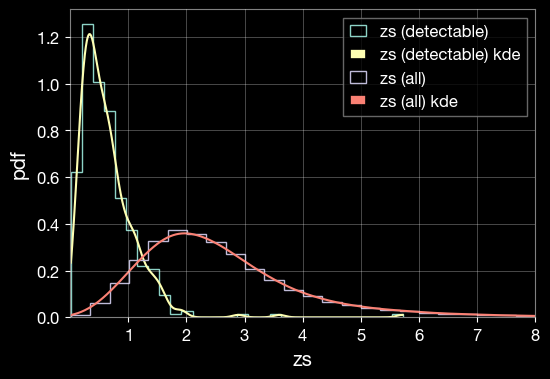

In [7]:
import matplotlib.pyplot as plt
from ler.utils import plots as lerplt

# input param_dict can be either a dictionary or a json file name that contains the parameters
plt.figure(figsize=(6, 4))
lerplt.param_plot(
    param_name='zs',
    param_dict='ler_data/gw_param_detectable.json',
    plot_label='zs (detectable)',
)
lerplt.param_plot(
    param_name='zs',
    param_dict='ler_data/gw_param.json',
    plot_label='zs (all)',
)
plt.xlim(0.001,8)
plt.xlabel('zs')
plt.ylabel('pdf')
plt.grid(alpha=0.4)
plt.show()

### 1.8 Examine Available Prior Functions

There are two ways of accessing the built-in GW parameter prior functions and their default parameters. 

#### 1.8.1 Accessing functions as Class Attributes

In [8]:
# Display all available GW prior sampler functions
print("Built-in GW parameter sampler functions and parameters:\n")
for func_name, func_params in ler.available_gw_prior.items():
    print(f"{func_name}:")
    
    if isinstance(func_params, dict):
        for param_name, param_value in func_params.items():
            print(f"  {param_name}: {param_value}")
    else:
        print(f"  {func_params}")
    print()

Built-in GW parameter sampler functions and parameters:

zs:
  merger_rate_density_based_source_redshift: None

mass_1_source:
  broken_powerlaw_plus_2peaks: {'param_name': 'mass_1_source', 'sampler_type': 'broken_powerlaw_plus_2peaks', 'lam_0': 0.361, 'lam_1': 0.586, 'mpp_1': 9.764, 'sigpp_1': 0.649, 'mpp_2': 32.763, 'sigpp_2': 3.918, 'mlow_1': 5.059, 'delta_m_1': 4.321, 'break_mass': 35.622, 'alpha_1': 1.728, 'alpha_2': 4.512, 'mmax': 300.0, 'normalization_size': 500}
  powerlaw_plus_peak: {'param_name': 'mass_1_source', 'sampler_type': 'powerlaw_plus_peak', 'mminbh': 4.98, 'mmaxbh': 112.5, 'alpha': 3.78, 'mu_g': 32.27, 'sigma_g': 3.88, 'lambda_peak': 0.03, 'delta_m': 4.8, 'normalization_size': 500}
  truncated_normal: {'param_name': 'mass_1_source', 'sampler_type': 'truncated_normal', 'mu': 1.4, 'sigma': 0.68, 'x_min': 1.0, 'x_max': 2.5}
  uniform: {'param_name': 'mass_1_source', 'sampler_type': 'uniform', 'x_min': 1.0, 'x_max': 2.5}
  powerlaw: {'param_name': 'mass_1_source', 'samp

In [9]:
# display the default GW parameter sampler function and its parameters
print("Built-in GW related functions and parameters:\n")
for func_name, func_params in ler.available_gw_functions.items():
    print(f"{func_name}:")
    
    if isinstance(func_params, dict):
        for param_name, param_value in func_params.items():
            print(f"  {param_name}: {param_value}")
    else:
        print(f"  {func_params}")
    print()

Built-in GW related functions and parameters:

merger_rate_density:
  merger_rate_density_madau_dickinson_belczynski_ng: {'param_name': 'merger_rate_density', 'function_type': 'merger_rate_density_madau_dickinson_belczynski_ng', 'R0': 1.9e-08, 'alpha_F': 2.57, 'beta_F': 5.83, 'c_F': 3.36}
  merger_rate_density_bbh_oguri2018: {'param_name': 'merger_rate_density', 'function_type': 'merger_rate_density_bbh_oguri2018', 'R0': 1.9e-08, 'b2': 1.6, 'b3': 2.1, 'b4': 30}
  merger_rate_density_madau_dickinson2014: {'param_name': 'merger_rate_density', 'function_type': 'merger_rate_density_madau_dickinson2014', 'R0': 8.9e-08, 'a': 0.015, 'b': 2.7, 'c': 2.9, 'd': 5.6}
  sfr_with_time_delay: {'param_name': 'merger_rate_density', 'function_type': 'sfr_with_time_delay', 'R0': 1.9e-08, 'a': 0.01, 'b': 2.6, 'c': 3.2, 'd': 6.2, 'td_min': 0.01, 'td_max': 10.0}
  merger_rate_density_bbh_popIII_ken2022: {'param_name': 'merger_rate_density', 'function_type': 'merger_rate_density_bbh_popIII_ken2022', 'R0': 1.

#### 1.8.2 Accessing functions from the ler.gw_source_population module

In [10]:
import ler.gw_source_population as gsp

for prior in gsp.available_prior_list():
    print(prior)

merger_rate_density_bbh_oguri2018_function
merger_rate_density_bbh_popIII_ken2022_function
merger_rate_density_madau_dickinson2014_function
merger_rate_density_madau_dickinson_belczynski_ng_function
merger_rate_density_bbh_primordial_ken2022_function
sfr_madau_fragos2017_with_bbh_td
sfr_madau_dickinson2014_with_bbh_td
sfr_madau_fragos2017_with_bns_td
sfr_madau_dickinson2014_with_bns_td
sfr_madau_fragos2017
sfr_madau_dickinson2014
ng2022_lognormal_joint_pdf
binary_masses_BBH_popIII_lognormal_rvs
binary_masses_BBH_primordial_lognormal_rvs
bimodal_pdf
binary_masses_BNS_bimodal_rvs
broken_powerlaw_pdf
gaussian_plus_isotropic_pdf
gaussian_plus_isotropic_joint_pdf
powerlaw_pdf
powerlaw_rvs
truncated_normal_pdf
truncated_normal_rvs
powerlaw_with_smoothing
powerlaw_plus_peak_pdf
powerlaw_plus_peak_function
powerlaw_plus_peak_rvs
broken_powerlaw_plus_2peaks_pdf
broken_powerlaw_plus_2peaks_function
broken_powerlaw_plus_2peaks_rvs
mass_ratio_powerlaw_with_smoothing_pdf
mass_ratio_powerlaw_with_sm

In [11]:
# use the following code to inspect one of the merger rate density function
# print(gsp.merger_rate_density_bbh_oguri2018.__doc__)

# Test one of the merger rate density function
print("\nTesting merger_rate_density_bbh_oguri2018 function")
zs =  np.array([0.1, 0.2, 0.3])
print(f"Redshifts: {zs}")
print(f"Merger Rate Denisty: {gsp.merger_rate_density_bbh_oguri2018_function(zs)} Mpc^-3 yr^-1")


Testing merger_rate_density_bbh_oguri2018 function
Redshifts: [0.1 0.2 0.3]
Merger Rate Denisty: [2.21298914e-08 2.57321630e-08 2.98600744e-08] Mpc^-3 yr^-1


---

## Part 2: Custom Functions and Parameters

This section demonstrates how to customize GWRATES with your own sampling functions and detection criteria. We'll create a BNS (Binary Neutron Star) example with custom settings:

| Component | Custom Configuration | Default (BBH) |
| :--- | :--- | :--- |
| **Event Type** | BNS (non-spinning) | BBH (spinning, aligned) |
| **Merger Rate** | Madau-Dickinson (2014) | GWTC-4 based |
| **Source Masses** | Uniform 1.0-2.3 $M_{\odot}$ | Truncated Normal |
| **Detectors** | 3G (ET, CE), SNR > 12 | O4 (H1, L1, V1), SNR > 10 |

**Notes:**
- **GW parameter sampling priors**: Should be a function with `size` as the only input argument. Can also be a class object of `ler.utils.FunctionConditioning`.
- **Merger rate density**: Should be a function of F(z).

### 2.2 Define Event Type with Non-Spinning Configuration

Using `event_type='BNS'` in the LeR class initialization will default to the following GW parameter priors corresponding to BNS. Other allowed event types are 'BBH' and 'NSBH'.

```python
    gw_functions = dict(
        merger_rate_density = 'merger_rate_density_madau_dickinson2014', 
    ),
    gw_functions_params = dict(
        merger_rate_density = dict(
            param_name='merger_rate_density', 
            function_type='merger_rate_density_madau_dickinson2014', 
            'R0': 89 * 1e-9, 'a': 0.015, 'b': 2.7, 'c': 2.9, 'd': 5.6
        ),
    ),
    gw_priors = dict(
        mass_1_source = 'truncated_normal',
        mass_2_source = 'truncated_normal',
        mass_ratio = None,
        a_1 = 'uniform',
        a_2 = 'uniform',
    ),
    gw_priors_params= dict(
        mass_1_source = dict(
            param_name='mass_1_source', sampler_type='truncated_normal',
            mu=1.4, sigma=0.68, x_min=1.0, x_max=2.5
        ),
        mass_2_source = dict(
            param_name='mass_2_source', sampler_type='truncated_normal',
            mu=1.4, sigma=0.68, x_min=1.0, x_max=2.5
        ),
        mass_ratio = None,
        a_1 = dict(
            param_name='a_1', sampler_type='uniform',
            xmin=-0.4, xmax=0.4
        ),
        a_2 = dict(
            param_name='a_2', sampler_type='uniform',
            xmin=-0.4, xmax=0.4
        ),
    ),
```

We will change some of these priors with our custom ones in the next sections.

For non-spinning configuration (faster calculation in our example), we can set:

```python
    spin_zero=True,
    spin_precession=False,
```

### 2.2 Define Custom Merger Rate Density

Using the default BNS merger rate density prior model, we change the local merger rate density from the default value of $R_0 = 89 \times 10^{-9} \, \text{Mpc}^{-3}\text{yr}^{-1}$ (GWTC-4) to $R_0 = 105.5 \times 10^{-9} \, \text{Mpc}^{-3}\text{yr}^{-1}$ (GWTC-3). 

### 2.3 Define Custom Merger Rate Density

Using the default BNS merger rate density prior model, we change the local merger rate density from the default value of $R_0 = 89 \times 10^{-9} \, \text{Mpc}^{-3}\text{yr}^{-1}$ (GWTC-4) to $R_0 = 105.5 \times 10^{-9} \, \text{Mpc}^{-3}\text{yr}^{-1}$ (GWTC-3).

In [12]:
# Use built-in Madau-Dickinson (2014) SFR based merger rate density for BNS
merger_rate_density_function = 'merger_rate_density_madau_dickinson2014'

# Custom parameters for merger rate density (Madau-Dickinson model)
merger_rate_density_input_args = dict(
    param_name='merger_rate_density',
    function_type='merger_rate_density_madau_dickinson2014',
    R0=89e-9,      # Local merger rate density (Mpc^-3 yr^-1)
    a=0.015,       # Evolution parameter a
    b=2.7,         # Evolution parameter b
    c=2.9,         # Evolution parameter c
    d=5.6,         # Evolution parameter d
)

print("Merger rate density function:", merger_rate_density_function)
print("Parameters:", merger_rate_density_input_args)

Merger rate density function: merger_rate_density_madau_dickinson2014
Parameters: {'param_name': 'merger_rate_density', 'function_type': 'merger_rate_density_madau_dickinson2014', 'R0': 8.9e-08, 'a': 0.015, 'b': 2.7, 'c': 2.9, 'd': 5.6}


### 2.1 Custom Source Frame Masses ($m_1^{src}$, $m_2^{src}$)

Using a uniform distribution to sample the binary masses mass_1_source and mass_2_source. Swapping of values if mass_1_source < mass_2_source will be done internally.

In [13]:
import numpy as np
from numba import njit

mmin=1.0
mmax=2.5

# define your custom function
# it should have 'size' as the only argument
# the same function will be used to sample both mass_1_source and mass_2_source. The code will swap the values if mass_1_source < mass_2_source.
@njit
def source_frame_masses_uniform(size):
    """
    Function to sample mass1 or mass2 from a uniform distribution between mmin and mmax.

    Parameters
    ----------
    size : `int`
        Number of samples to draw

    Returns
    -------
    mass_source : `numpy.ndarray`
        Array of mass samples in the source frame (Msun)
    """

    mass_source = np.random.uniform(mmin, mmax, size)

    return mass_source

# test
mass_source = source_frame_masses_uniform(size=5)
print(f"mass: {mass_source} M_sun")

mass: [2.49467409 1.90795724 2.2845663  2.11791596 1.04725876] M_sun


### 2.4 Define Custom Detection Criteria

Create a custom detection function using 3G detectors (Einstein Telescope and Cosmic Explorer) with a higher SNR threshold. We use `pdet = optimal_SNR_net > 12` instead of the default `pdet` based on `observed_SNR_net > 10`.

This function takes GW parameters as input and returns Pdet as a boolean or probability array indicating detectability.

In [14]:
from gwsnr import GWSNR

# Define mass and redshift ranges for BNS
mmin = 1.0
mmax = 2.3
zmin = 0.0
zmax = 10.0
snr_threshold_network = 12  # SNR threshold for detection (default: 10) 

# Initialize GWSNR for 3G detectors (no spins for BNS)
gwsnr_3g = GWSNR(
    npool=4,
    ifos=['ET', 'CE'],  # Einstein Telescope and Cosmic Explorer
    snr_method='interpolation_no_spins',  # No spin precession for BNS
    mtot_min=2*mmin*(1+zmin),
    mtot_max=2*mmax*(1+zmax),
    sampling_frequency=2048.0,
    waveform_approximant='IMRPhenomD',
    minimum_frequency=20.0,
    gwsnr_verbose=False,
)

def detection_criteria(gw_param_dict):
    """
    Determine if a gravitational wave event is detectable based on SNR threshold.
    
    Parameters
    ----------
    gw_param_dict : dict
        Dictionary containing GW parameters including mass_1, mass_2, luminosity_distance, etc.
    
    Returns
    -------
    dict
        Dictionary with 'pdet_net' (boolean detection array) and 'optimal_snr_net'
    """
    result_dict = {}
    
    # Calculate optimal SNR for all detectors
    snr_dict = gwsnr_3g.optimal_snr(gw_param_dict=gw_param_dict)
    
    # Apply detection threshold
    result_dict['pdet_net'] = snr_dict['optimal_snr_net'] > snr_threshold_network
    
    return result_dict

print("Custom detection criteria defined for 3G detectors (ET + CE)")
print(f"Detection network SNR threshold: {snr_threshold_network}")

# Test the detection criteria function
gw_param_dict = dict(
    mass_1 = np.array([2.0, 2.0]),
    mass_2 = np.array([1.0, 1.0]),
    luminosity_distance = np.array([1000.0, 10000.0]),
)
pdet = detection_criteria(gw_param_dict=gw_param_dict)
print("\nTest detection calculation:")
print(f"  mass_1 array: {gw_param_dict['mass_1']}")
print(f"  mass_2 array: {gw_param_dict['mass_2']}")
print(f"  luminosity_distance array: {gw_param_dict['luminosity_distance']}")
print(f"  Pdet result: {pdet}")


Initializing GWSNR class...

Interpolator will be generated for ET1 detector at ./interpolator_json/ET1/partialSNR_dict_1.json
Interpolator will be generated for ET2 detector at ./interpolator_json/ET2/partialSNR_dict_1.json
Interpolator will be generated for ET3 detector at ./interpolator_json/ET3/partialSNR_dict_1.json
Interpolator will be generated for CE detector at ./interpolator_json/CE/partialSNR_dict_1.json
Please be patient while the interpolator is generated
Generating interpolator for ['ET1', 'ET2', 'ET3', 'CE'] detectors


100%|█████████████████████████████████████████████████████████| 4000/4000 [00:03<00:00, 1134.35it/s]



Saving Partial-SNR for ET1 detector with shape (20, 200)

Saving Partial-SNR for ET2 detector with shape (20, 200)

Saving Partial-SNR for ET3 detector with shape (20, 200)

Saving Partial-SNR for CE detector with shape (20, 200)


Custom detection criteria defined for 3G detectors (ET + CE)
Detection network SNR threshold: 12

Test detection calculation:
  mass_1 array: [2. 2.]
  mass_2 array: [1. 1.]
  luminosity_distance array: [ 1000. 10000.]
  Pdet result: {'pdet_net': array([ True, False])}


### 2.5 Initialize GWRATES with Custom Settings

Create a GWRATES instance with the custom functions and parameters defined above.

In [15]:
from ler import GWRATES

# Initialize GWRATES with custom functions
ler_custom = GWRATES(
    # LeR setup parameters
    npool=6,
    z_min=0.001,
    z_max=10,
    verbose=True,
    event_type="BNS",  # Binary Neutron Star
    spin_zero=True,
    
    # Custom source parameter priors
    gw_functions=dict(
        merger_rate_density=merger_rate_density_function,
    ),
    gw_functions_params=dict(
        merger_rate_density=merger_rate_density_input_args,
    ),
    gw_priors=dict(
        mass_1_source=source_frame_masses_uniform,
        mass_2_source=source_frame_masses_uniform,
    ),
    gw_priors_params=dict(
        mass_1_source=dict(
            param_name='mass_1_source',
            sampler_type='source_frame_masses_uniform',
            mmin=1.0,
            mmax=2.5,
        ),
        mass_2_source=dict(
            param_name='mass_2_source',
            sampler_type='source_frame_masses_uniform',
            mmin=1.0,
            mmax=2.5,
        ),
    ),
    
    # Custom detection criteria
    pdet_finder=detection_criteria,
    ler_directory='./ler_data_custom',  # Save in a separate directory
)


Initializing GWRATES class...


Initializing CBCSourceRedshiftDistribution class...

luminosity_distance interpolator will be generated at ./interpolator_json/luminosity_distance/luminosity_distance_1.json
differential_comoving_volume interpolator will be generated at ./interpolator_json/differential_comoving_volume/differential_comoving_volume_1.json
using ler available merger rate density model: merger_rate_density_madau_dickinson2014
merger_rate_density_madau_dickinson2014 interpolator will be generated at ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson2014_5.json
merger_rate_density_madau_dickinson2014_detector_frame interpolator will be generated at ./interpolator_json/merger_rate_density/merger_rate_density_madau_dickinson2014_detector_frame_6.json
merger_rate_density_based_source_redshift interpolator will be generated at ./interpolator_json/merger_rate_density_based_source_redshift/merger_rate_density_based_source_redshift_2.json

Initializing CBCSo

### 2.6 Sample GW Parameters with Custom Settings

In [16]:
# Sample GW population with custom settings
gw_params_custom = ler_custom.gw_cbc_statistics(
    size=100000,
    batch_size=50000,
    resume=False,  # Start fresh
    output_jsonfile='custom_gw_params.json'
)

print(f"\nSampled {len(gw_params_custom['zs'])} custom BNS events")

Simulated GW params will be stored in ./ler_data_custom/custom_gw_params.json
removing ./ler_data_custom/custom_gw_params.json if it exists
Batch no. 1
sampling gw source params...
calculating pdet...
Batch no. 2
sampling gw source params...
calculating pdet...
saving all gw parameters in ./ler_data_custom/custom_gw_params.json 

Sampled 100000 custom BNS events


### 2.7 Calculate Rates with Custom Settings

In [17]:
# Calculate detection rates with custom settings
detectable_rate_custom, gw_param_detectable_custom = ler_custom.gw_rate()

# Calculate fraction of detectable events
total_rate_custom = ler_custom.normalization_pdf_z
fraction_detectable = detectable_rate_custom / total_rate_custom

print(f"\n=== Custom BNS Detection Results (3G Detectors Sensitivity) ===")
print(f"Detectable BNS event rate: {detectable_rate_custom:.4e} events per year")
print(f"Total BNS event rate: {total_rate_custom:.4e} events per year")
print(f"Detectable fraction: {fraction_detectable*100:.2f}%")

Getting gw parameters from json file ./ler_data_custom/custom_gw_params.json...
total GW event rate (yr^-1): 86942.48022792942
number of simulated GW detectable events: 26219
number of simulated all GW events: 100000
storing detectable params in ./ler_data_custom/gw_param_detectable.json

=== Custom BNS Detection Results (3G Detectors Sensitivity) ===
Detectable BNS event rate: 8.6942e+04 events per year
Total BNS event rate: 3.3160e+05 events per year
Detectable fraction: 26.22%


### 2.8 Compare Default and Custom Mass Distributions

Compare the custom uniform mass distribution with the internal BNS normal distribution.

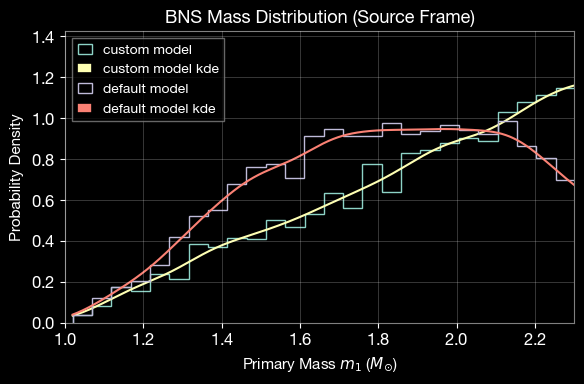

In [18]:
import ler.utils as lerplt
import matplotlib.pyplot as plt

# Custom mass distributions for comparison (uniform)
m1_custom = source_frame_masses_uniform(size=5000)
m2_custom = source_frame_masses_uniform(size=5000)
# swapping to ensure mass_1 >= mass_2
idx = m1_custom < m2_custom
m1_custom[idx], m2_custom[idx] = m2_custom[idx], m1_custom[idx]

# internal BNS normal distribution in LeR
kwargs = dict(
    param_name = "mass_1_source",
    sampler_type = "truncated_normal",
    mu=1.4, sigma=0.68, x_min=1.0, x_max=2.5
)
m1_default = ler.truncated_normal(size=5000, **kwargs)
m2_default = ler.truncated_normal(size=5000, **kwargs)
# swapping to ensure mass_1 >= mass_2
idx = m1_default < m2_default
m1_default[idx], m2_default[idx] = m2_default[idx], m1_default[idx]

custom_dict = dict(mass_1=m1_custom)
default_dict = dict(mass_1=m1_default)

# Plot comparison
plt.figure(figsize=(6, 4))
lerplt.param_plot(
    param_name="mass_1", 
    param_dict=custom_dict, # or the json file name
    plot_label='custom model',
);
lerplt.param_plot(
    param_name="mass_1", 
    param_dict=default_dict,
    plot_label='default model',
);
plt.xlabel(r'Primary Mass $m_1$ ($M_{\odot}$)', fontsize=11)
plt.ylabel(r'Probability Density', fontsize=11)
plt.title('BNS Mass Distribution (Source Frame)', fontsize=13, fontweight='bold')
plt.xlim(1.0, 2.3)
plt.grid(alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

---

## Part 3: Advanced Sampling - Generating Detectable Events

This section demonstrates how to generate a specific number of detectable events and monitor detection rate convergence.

### 3.1 Initialize GWRATES for N-Event Sampling

In [19]:
from ler import GWRATES
import numpy as np
import matplotlib.pyplot as plt

# Create a new GWRATES instance for N-event sampling
ler_n_events = GWRATES(
    npool=6,
    verbose=False,
)


Initializing GWRATES class...



### 3.2 Sample Until N Detectable Events Are Found

This function will:
- Continue sampling in batches until at least N detectable events are found
- Monitor rate convergence using a stopping criteria (e.g., relative rate difference < 0.5%)
- Calculate rates dynamically at each batch
- Allow resuming from the last batch if interrupted

In [20]:
# Sample until we have at least 10,000 detectable events with converged rates
detectable_rate_n, gw_param_detectable_n = ler_n_events.selecting_n_gw_detectable_events(
    size=10000,  # Target number of detectable events
    batch_size=100000,  # Events per batch
    stopping_criteria=dict(
        relative_diff_percentage=0.5,  # Stop when rate change < 0.5% (use 0.1% for better convergence)
        number_of_last_batches_to_check=4  # Check last 4 batches
    ),
    pdet_threshold=0.5,  # Probability threshold for detection
    resume=False,  # Start fresh
    output_jsonfile='gw_params_n_detectable.json',
    meta_data_file='meta_gw.json',  # Store metadata (rates per batch)
    pdet_type='boolean',
    trim_to_size=False,  # Keep all events found until convergence
)

print(f"\n=== N-Event Sampling Results ===")
print(f"Detectable event rate: {detectable_rate_n:.4e} events per year")
print(f"Collected number of detectable events: {len(gw_param_detectable_n['zs'])}")

stopping criteria set to when relative difference of total rate for the last 4 cumulative batches is less than 0.5%.
sample collection will stop when the stopping criteria is met and number of detectable events exceeds the specified size.
removing ./ler_data/gw_params_n_detectable.json if it exists
removing ./ler_data/meta_gw.json if it exists
collected number of detectable events =  0
collected number of detectable events (batch) =  392
collected number of detectable events (cumulative) =  392
total number of events =  100000
total rate (yr^-1): 359.0085047458413
collected number of detectable events (batch) =  349
collected number of detectable events (cumulative) =  741
total number of events =  200000
total rate (yr^-1): 339.3179872661587
collected number of detectable events (batch) =  371
collected number of detectable events (cumulative) =  1112
total number of events =  300000
total rate (yr^-1): 339.47062693654385
collected number of detectable events (batch) =  373
collected 

### 3.3 Analyze Rate Convergence

Plot the evolution of the detection rate across batches to verify convergence.

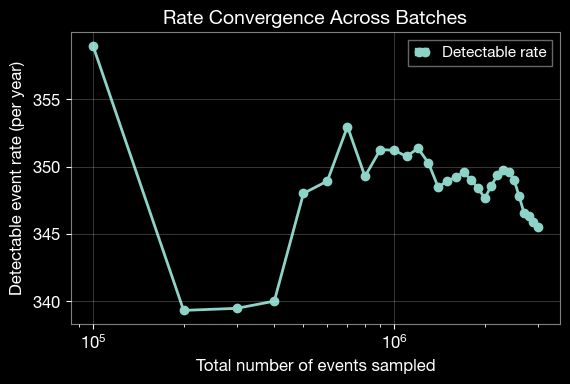

In [21]:
import matplotlib.pyplot as plt
from ler.utils import get_param_from_json

# Load metadata containing rates for each batch
meta_data = get_param_from_json(ler_n_events.ler_directory + '/meta_gw.json')

# Plot rate vs sampling size
plt.figure(figsize=(6, 4))
plt.plot(
    meta_data['events_total'],
    meta_data['total_rate'],
    'o-',
    linewidth=2,
    markersize=6,
    label='Detectable rate'
)

plt.xlabel('Total number of events sampled', fontsize=12)
plt.ylabel('Detectable event rate (per year)', fontsize=12)
plt.title('Rate Convergence Across Batches', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.xscale('log')
plt.tight_layout()
plt.show()

### 3.4 Assess Rate Stability

Calculate the average rate from the last batches to verify convergence.

In [22]:
import numpy as np

# Select rates from the last batches
idx_converged = [-4, -3, -2, -1]
rates_converged = np.array(meta_data['total_rate'])[idx_converged]

if len(rates_converged) > 0:
    mean_rate = rates_converged.mean()
    std_rate = rates_converged.std()
    
    print(f"\n=== Rate Stability Analysis ===")
    print(f"Number of converged batches: {len(rates_converged)}")
    print(f"Mean rate (converged): {mean_rate:.4e} events per year")
    print(f"Standard deviation: {std_rate:.4e} events per year")
    print(f"Relative uncertainty: {(std_rate/mean_rate)*100:.2f}%")
else:
    print("Not enough batches to assess convergence.")


=== Rate Stability Analysis ===
Number of converged batches: 4
Mean rate (converged): 3.4607e+02 events per year
Standard deviation: 3.9236e-01 events per year
Relative uncertainty: 0.11%


### 3.5 Compare All Sampled and Detectable Event Parameters

Create an overlapping visualization comparing the parameter distributions of all sampled events with detectable events only.

In [23]:
# generate CBC (all) parameters
gw_param = ler_n_events.gw_cbc_statistics(10000, resume=False)

Simulated GW params will be stored in ./ler_data/gw_param.json
removing ./ler_data/gw_param.json if it exists
Batch no. 1
sampling gw source params...
calculating pdet...
saving all gw parameters in ./ler_data/gw_param.json 


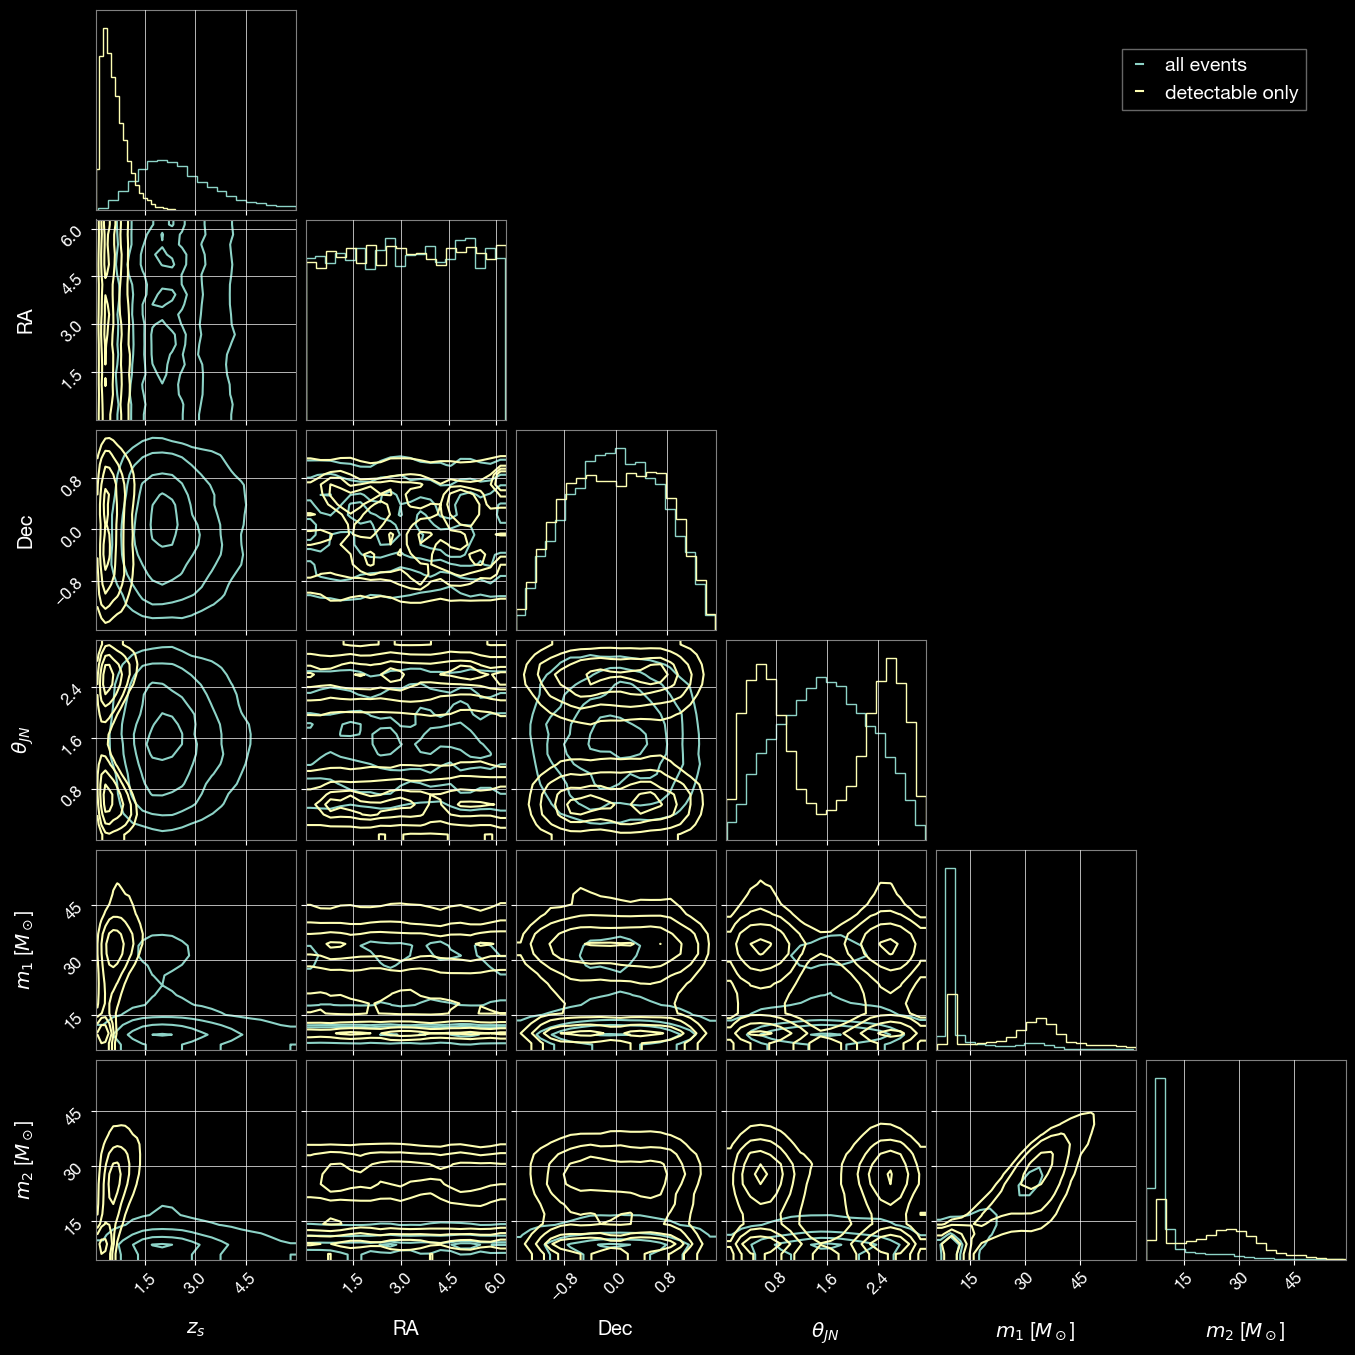

In [24]:
import corner
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from ler.utils import get_param_from_json

param = get_param_from_json('ler_data/gw_param.json')
param_detectable = get_param_from_json('./ler_data/gw_params_n_detectable.json')

# select mass_1_source less than 90 solar masses to focus on the more common stellar-mass black hole events
mask_all = (param['mass_1_source'] < 60) & (param['zs'] < 6.0)
mask_detectable = (param_detectable['mass_1_source'] < 60) & (param_detectable['zs'] < 6.0)

# Parameters to compare
param_names = ['zs', 'ra', 'dec', 'theta_jn', 'mass_1_source', 'mass_2_source']
labels = ['$z_s$', 'RA', 'Dec', r'$\theta_{JN}$', '$m_1$ [$M_\odot$]', '$m_2$ [$M_\odot$]']

# Prepare data for corner plot
samples_all = np.stack([param[p][mask_all] for p in param_names], axis=1)
samples_detectable = np.stack([param_detectable[p][mask_detectable] for p in param_names], axis=1)

# Generate corner plot
fig = corner.corner(
    samples_all, 
    labels=labels, 
    color='C0', 
    alpha=0.5,
    plot_density=False, plot_datapoints=False, smooth=0.8,
    hist_kwargs={'density': True}
)
blue_line = mlines.Line2D([], [], color='C0', label='all events')

# Plot detectable events
corner.corner(
    samples_detectable, 
    labels=labels, 
    color='C1', 
    alpha=0.5,
    fig=fig, 
    plot_density=False, plot_datapoints=False, smooth=0.8,
    hist_kwargs={'density': True}
)
orange_line = mlines.Line2D([], [], color='C1', label='detectable only')

# Add legend
fig.legend(handles=[blue_line, orange_line], loc='upper right', bbox_to_anchor=(0.95, 0.95), fontsize=14)

plt.show()

## Part 4: Model Uncertainty Consideration

Hyperparameter uncertainty was not included in the earlier examples for simplicity. Here we propagate uncertainty in the mass-model hyperparameters by drawing posterior samples and recomputing rates.

This gives a distribution of detectable GW rates (instead of one point estimate) and shows how inferred source distributions change under model uncertainty.

### 4.1 Median Hyperparameter Run

In [32]:
from ler.utils import get_param_from_json
from ler.gw_source_population import broken_powerlaw_plus_2peaks_rvs
from ler import GWRATES
import numpy as np
import matplotlib.pyplot as plt
import contextlib
from tqdm import tqdm

# Hyperparameter posterior samples for broken powerlaw + 2 peaks model (GWTC-4)
data = get_param_from_json("broken_powerlaw_plus_2peaks_hyperparameters.json")

hyper_keys = [
    "lam_0", "lam_1", "mpp_1", "sigpp_1", "mpp_2", "sigpp_2",
    "mlow_1", "delta_m_1", "break_mass", "alpha_1", "alpha_2",
]

def make_mass_1_sampler(hyp):
    """Return a mass_1_source sampler with fixed hyperparameters."""
    def sampler(size):
        return broken_powerlaw_plus_2peaks_rvs(
            size=size,
            lam_0=hyp["lam_0"],
            lam_1=hyp["lam_1"],
            mpp_1=hyp["mpp_1"],
            sigpp_1=hyp["sigpp_1"],
            mpp_2=hyp["mpp_2"],
            sigpp_2=hyp["sigpp_2"],
            mlow_1=hyp["mlow_1"],
            delta_m_1=hyp["delta_m_1"],
            break_mass=hyp["break_mass"],
            alpha_1=hyp["alpha_1"],
            alpha_2=hyp["alpha_2"],
            mmax=300.0,
        )
    return sampler

print(f"Loaded posterior chain with {len(data['lam_0'])} hyperparameter samples.")

Loaded posterior chain with 500 hyperparameter samples.


In [33]:
# Run once using median hyperparameter values
sample_size = 100000

median_hyp = {k: float(np.median(data[k])) for k in hyper_keys}
mass_1_source_rvs_median = make_mass_1_sampler(median_hyp)

ler = GWRATES(
    npool=6,
    event_type="BBH",
    gw_priors=dict(
        mass_1_source=mass_1_source_rvs_median,
    ),
    spin_zero=False,
    spin_precession=True,
    verbose=False,
    ler_directory="./ler_data_model_uncertainty_median",
)

with contextlib.redirect_stdout(None):
    gw_param_median = ler.gw_cbc_statistics(
        size=sample_size,
        batch_size=100000,
        resume=False,
    )
    gw_rate_median, gw_param_detectable_median = ler.gw_rate(gw_param=gw_param_median)

m1_samples_median = gw_param_median["mass_1_source"]

print(f"Detectable GW rate (median hyperparameters): {gw_rate_median:.3f} events/year")
print(f"Total sampled events (median run): {len(m1_samples_median)}")


Initializing GWRATES class...

Detectable GW rate (median hyperparameters): 314.132 events/year
Total sampled events (median run): 100000


### 4.2 Hyperparameter Posterior Propagation

Generate multiple realizations by sampling hyperparameters from their posterior chain and recomputing the detectable GW rate for each realization.

Use smaller values of `sample_size` and `loop_size` for quick tests, and increase them for production-quality uncertainty estimates.

In [34]:
sample_size = 100000
loop_size = 10
rng = np.random.default_rng(1234)
idx = rng.choice(len(data["lam_0"]), size=loop_size, replace=False)

m1_samples_all = []
gw_rates = []

for j in tqdm(idx, total=loop_size, ncols=100):

    with contextlib.redirect_stdout(None):
        # Update only the mass model hyperparameters on the existing GWRATES instance
        hyp = {k: float(data[k][j]) for k in hyper_keys}
        mass_1_source_rvs_median = make_mass_1_sampler(hyp)

        # redefine the mass_1_source sampler with the new hyperparameters
        ler.mass_1_source = mass_1_source_rvs_median

        gw_param_i = ler.gw_cbc_statistics(
            size=sample_size,
            batch_size=100000,
            resume=False,
            output_jsonfile="gw_param_tmp.json",
        )
        gw_rate_i, _ = ler.gw_rate(
            gw_param=gw_param_i,
            output_jsonfile="gw_param_detectable_tmp.json",
        )

        m1_samples_all.append(gw_param_i["mass_1_source"])
        gw_rates.append(gw_rate_i)

m1_samples_all = np.array(m1_samples_all, dtype=object)
gw_rates = np.array(gw_rates, dtype=float)

print(f"Completed {loop_size} posterior draws.")
print(f"Rate mean: {gw_rates.mean():.3f} events/year")
print(f"Rate std:  {gw_rates.std():.3f} events/year")
# loop_size=100: 3m 11.1s

100%|███████████████████████████████████████████████████████████████| 10/10 [00:17<00:00,  1.75s/it]

Completed 10 posterior draws.
Rate mean: 347.011 events/year
Rate std:  49.371 events/year


In [ ]:
# # save the results in a json file
# from ler.utils import append_json
# dict_ = dict(
#     m1_samples_all=m1_samples_all,
#     gw_rates=gw_rates,
# )
# # save the results in a json file
# append_json("GWRATES_model_uncertainty.json", dict_, replace=False);

# # load the results from the npz file
# from ler.utils import get_param_from_json

# results = get_param_from_json("GWRATES_model_uncertainty.json")
# m1_samples_all = results["m1_samples_all"]
# gw_rates = results["gw_rates"]

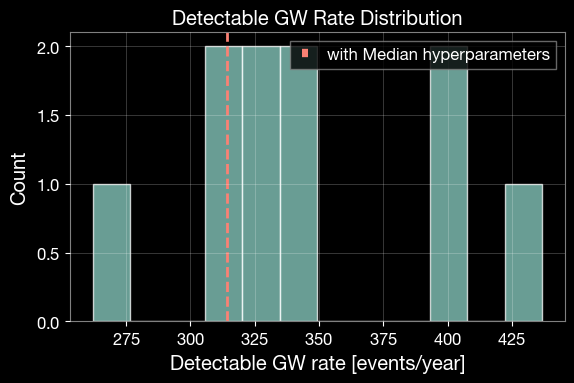

In [35]:
# 4.3 Visualize rate uncertainty from posterior hyperparameter propagation
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.hist(gw_rates, bins=12, alpha=0.75, color='C0', edgecolor='white')
ax.axvline(gw_rate_median, color='C3', linestyle='--', linewidth=2, label='with Median hyperparameters')
ax.set_title('Detectable GW Rate Distribution')
ax.set_xlabel('Detectable GW rate [events/year]')
ax.set_ylabel('Count')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

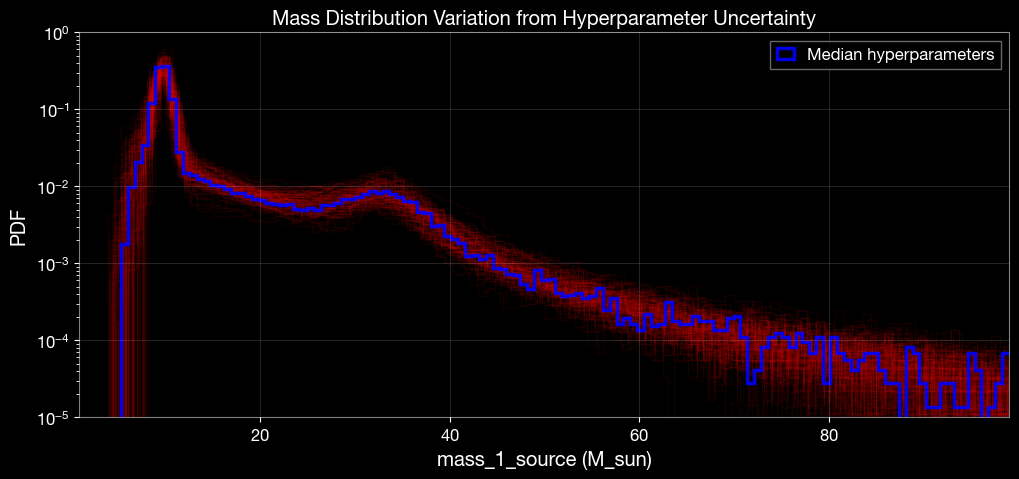

In [30]:
# Plot mass_1_source distribution overlays using posterior hyperparameter samples
plt.figure(figsize=(12, 5))
bins = 300

for arr in m1_samples_all:
    plt.hist(arr, bins=bins, density=True, alpha=0.08, color="red", histtype="step")

plt.hist(
    m1_samples_median,
    bins=bins,
    density=True,
    alpha=0.9,
    color="blue",
    histtype="step",
    label="Median hyperparameters",
    linewidth=2.5,
)

plt.yscale("log")
plt.ylim(1e-5, 1.0)
plt.xlim(1, 99)
plt.xlabel("mass_1_source (M_sun)")
plt.ylabel("PDF")
plt.title("Mass Distribution Variation from Hyperparameter Uncertainty")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

---

## Summary

This notebook demonstrated the key features of the `GWRATES` class:

1. **Basic Simulation:** Simulating GW populations and calculating detection rates
2. **Customization:** Using custom mass distributions, merger rate densities, and detection criteria
3. **Advanced Sampling:** Generating a specific number of detectable events and monitoring rate convergence
4. **Visualization:** Comparing distributions and analyzing results
5. **Model Uncertainty:** Propagating hyperparameter posterior uncertainty into detectable GW-rate estimates

For more examples and detailed documentation, visit the [ler documentation](https://ler.hemantaph.com).

**Key Takeaways:**
- GWRATES is flexible and supports custom prior functions
- Batching allows resumable simulations and memory-efficient sampling
- Rate convergence can be monitored and validated
- Hyperparameter posterior propagation provides uncertainty bands on rate predictions
- Results are automatically saved for reproducibility and further analysis